In [85]:
# import subprocess
# subprocess.run([
#     "pip", "install", "-q",
#     "albumentations", "opencv-python-headless",
#     "pandas", "matplotlib", "transformers", "accelerate"
# ], check=True)
# print('deps installed')

deps installed


## Data Loader, Initialization, Importing Libraries 

In [2]:
import sys, os
sys.path.append("/kaggle/input/datasets/atalgupta/src-code/src")

MODEL_NAME  = "CIDAS/clipseg-rd64-refined"
RUN_NAME    = "crackclip_v3"

PROCESSED_ROOT = "/kaggle/input/datasets/atalgupta/dataset/processed"
SPLITS_JSON    = "/kaggle/input/datasets/atalgupta/dataset/processed/splits.json"
PROMPTS_CSV    = "/kaggle/input/datasets/atalgupta/dataset/processed/prompts.csv"

IMAGE_SIZE  = (352, 352)

# ── training budget ────────────────────────────────────────────────────────
EPOCHS             = 100
BATCH_SIZE         = 4
ACCUMULATION_STEPS = 4       # effective batch = 16
PATIENCE           = 15      # was 7 — too tight, caused premature stop
SEED               = 42

# ── learning rates ─────────────────────────────────────────────────────────
LR_DECODER         = 1e-4    # CLIPSeg decoder
LR_ADAPTER         = 1e-5    # adapters — lower than decoder
WARMUP_EPOCHS      = 5

# ── unfreeze strategy ──────────────────────────────────────────────────────
UNFREEZE_EPOCH     = 15      # unfreeze last 6 encoder layers after this epoch
NUM_UNFREEZE       = 6       # how many encoder layers to unfreeze
UNFREEZE_BASE_LR   = 5e-6    # deepest layer LR
UNFREEZE_DECAY     = 0.8     # each shallower layer gets 0.8x less LR

# ── adapter ────────────────────────────────────────────────────────────────
ADAPTER_REDUCTION  = 4

# ── loss ───────────────────────────────────────────────────────────────────
LOSS_TYPE   = "bce_dice"     # single loss used for BOTH train and val
BCE_WEIGHT  = 0.5
DICE_WEIGHT = 0.5
POS_WEIGHT  = None

# ── resume (set these when continuing a run) ────────────────────────────────
START_EPOCH  = 1             # change to e.g. 51 when resuming
RESUME_CKPT  = None          # change to CKPT_DIR+'/best.pth' when resuming

# ── output paths — ALL inside /kaggle/working so they persist ──────────────
CKPT_DIR = f"/kaggle/working/checkpoints/{RUN_NAME}"
PRED_DIR = f"/kaggle/working/predictions/{RUN_NAME}"
VIZ_DIR  = f"/kaggle/working/visualisations/{RUN_NAME}"
METRICS_DIR = "/kaggle/working/metrics"

for d in [CKPT_DIR, PRED_DIR, VIZ_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Config OK')
print(f'  Epochs       : {START_EPOCH} → {EPOCHS}')
print(f'  Patience     : {PATIENCE}')
print(f'  LR decoder   : {LR_DECODER}')
print(f'  LR adapter   : {LR_ADAPTER}')
print(f'  Unfreeze at  : epoch {UNFREEZE_EPOCH+1}  ({NUM_UNFREEZE} layers)')
print(f'  Resume       : {RESUME_CKPT}')

Config OK
  Epochs       : 1 → 100
  Patience     : 15
  LR decoder   : 0.0001
  LR adapter   : 1e-05
  Unfreeze at  : epoch 16  (6 layers)
  Resume       : None


In [3]:
import json, random
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
from tqdm import tqdm
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

from dataset import SegDataset, build_loaders
from augmentations import get_transform
from losses import get_loss
from metrics import MetricTracker, BestModelTracker
from utils import (
    get_device, count_parameters,
    save_checkpoint, load_checkpoint,
    save_predictions, visualise_predictions, save_results,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print('Imports OK')

Imports OK


In [4]:
for path in [PROCESSED_ROOT, SPLITS_JSON, PROMPTS_CSV]:
    p = Path(path)
    print(f"{'OK' if p.exists() else 'MISSING'}  {path}")

OK  /kaggle/input/datasets/atalgupta/dataset/processed
OK  /kaggle/input/datasets/atalgupta/dataset/processed/splits.json
OK  /kaggle/input/datasets/atalgupta/dataset/processed/prompts.csv


In [5]:
with open(SPLITS_JSON) as f:
    splits = json.load(f)

prompts_df = pd.read_csv(PROMPTS_CSV)

print(f"Splits  seed={splits['seed']}")
print(f"  drywall  train={len(splits['drywall']['train'])}  val={len(splits['drywall']['val'])}  test={len(splits['drywall']['test'])}")
print(f"  cracks   train={len(splits['cracks']['train'])}  val={len(splits['cracks']['val'])}  test={len(splits['cracks']['test'])}")
print(f"Prompts  {len(prompts_df)} rows")

Splits  seed=42
  drywall  train=172  val=36  test=38
  cracks   train=778  val=166  test=168
Prompts  1358 rows


In [6]:
cfg = {
    "processed_root": PROCESSED_ROOT,
    "image_size"    : list(IMAGE_SIZE),
    "batch_size"    : BATCH_SIZE,
    "neg_prob"      : 0.3,
}

processor = CLIPSegProcessor.from_pretrained(MODEL_NAME)

train_loader, val_loader, test_loader = build_loaders(
    cfg          = cfg,
    prompts_df   = prompts_df,
    splits       = splits,
    transform_fn = lambda split, size: get_transform(split, size),
    processor    = processor,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

Train sampler  drywall=172  cracks=778  ratio=4.5:1
Train batches : 238
Val batches   : 51
Test batches  : 206


In [ ]:

# CrackCLIP adapter

class BottleneckAdapter(nn.Module):
    def __init__(self, embed_dim: int, reduction: int = 4):
        super().__init__()
        hidden = embed_dim // reduction
        self.norm = nn.LayerNorm(embed_dim)
        self.down = nn.Linear(embed_dim, hidden)
        self.act  = nn.GELU()
        self.up   = nn.Linear(hidden, embed_dim)
        nn.init.kaiming_uniform_(self.down.weight)
        nn.init.zeros_(self.down.bias)
        nn.init.zeros_(self.up.weight)   # zero-init → starts as identity
        nn.init.zeros_(self.up.bias)

    def forward(self, x):
        return x + self.up(self.act(self.down(self.norm(x))))


class CLIPSegWithAdapters(nn.Module):
    def __init__(self, model_name: str, reduction: int = 4):
        super().__init__()
        self.clipseg = CLIPSegForImageSegmentation.from_pretrained(model_name)
        embed_dim  = self.clipseg.clip.config.vision_config.hidden_size
        num_layers = len(self.clipseg.clip.vision_model.encoder.layers)

        # adapters only on last 4 layers
        # low-level edges/texture already well-represented in CLIP
        self.adapters = nn.ModuleList([
            BottleneckAdapter(embed_dim, reduction)
            if i >= num_layers - 4 else nn.Identity()
            for i in range(num_layers)
        ])

    def forward(self, pixel_values=None, input_ids=None, **kwargs):
        hooks   = []
        encoder = self.clipseg.clip.vision_model.encoder
        for layer, adapter in zip(encoder.layers, self.adapters):
            def make_hook(adp):
                def hook_fn(module, input, output):
                    hidden = adp(output[0])
                    return (hidden,) + output[1:]
                return hook_fn
            hooks.append(layer.register_forward_hook(make_hook(adapter)))
        try:
            return self.clipseg(pixel_values=pixel_values,
                                input_ids=input_ids, **kwargs)
        finally:
            for h in hooks:
                h.remove()


device = get_device()
model  = CLIPSegWithAdapters(MODEL_NAME, reduction=ADAPTER_REDUCTION).to(device)
print('Model created')

Using GPU: Tesla T4


model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model created


In [ ]:


# freeze entire backbone
for param in model.clipseg.clip.parameters():
    param.requires_grad = False

# unfreeze decoder + adapters (always trainable)
for param in model.clipseg.decoder.parameters():
    param.requires_grad = True
for param in model.adapters.parameters():
    if not isinstance(model.adapters[0], type(param)):  # skip Identity params
        param.requires_grad = True
# simpler: just set adapters directly
for adapter in model.adapters:
    if hasattr(adapter, 'parameters'):
        for param in adapter.parameters():
            param.requires_grad = True

# if resuming past unfreeze point, pre-unfreeze encoder layers NOW
# so the optimizer is built with the complete set of param groups from scratch
encoder_layers = model.clipseg.clip.vision_model.encoder.layers
already_unfrozen = START_EPOCH > UNFREEZE_EPOCH

if already_unfrozen:
    print(f'Resume: pre-unfreezing last {NUM_UNFREEZE} encoder layers')
    for layer in encoder_layers[-NUM_UNFREEZE:]:
        for param in layer.parameters():
            param.requires_grad = True

# build param groups
param_groups = [
    {"params": list(model.clipseg.decoder.parameters()), "lr": LR_DECODER},
    {"params": [p for a in model.adapters
                for p in a.parameters()
                if p.requires_grad],                      "lr": LR_ADAPTER},
]

# if resuming past unfreeze, add encoder groups now
if already_unfrozen:
    for i, layer in enumerate(reversed(encoder_layers[-NUM_UNFREEZE:])):
        lr = UNFREEZE_BASE_LR * (UNFREEZE_DECAY ** i)
        param_groups.append({
            "params": list(layer.parameters()),
            "lr"    : lr,
        })
        print(f'  encoder layer {-1-i:2d}  lr={lr:.2e}')

optimizer = AdamW(param_groups, weight_decay=1e-4)

# scheduler: cosine warm restarts
# LR resets at epoch T_0, then 2*T_0, etc. never decays to zero
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-6
)

# load checkpoint if resuming
if RESUME_CKPT is not None:
    ckpt = torch.load(RESUME_CKPT, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['state_dict'])
    # advance scheduler to resume epoch
    for _ in range(START_EPOCH - 1):
        scheduler.step()
    print(f'Resumed from {RESUME_CKPT}')
    print(f'  Checkpoint epoch : {ckpt["epoch"]}')
    print(f'  Val IoU          : {ckpt["metrics"]["iou"]:.4f}')

criterion = get_loss({
    'loss_type'  : LOSS_TYPE,
    'bce_weight' : BCE_WEIGHT,
    'dice_weight': DICE_WEIGHT,
    'pos_weight' : POS_WEIGHT,
})
scaler = GradScaler('cuda')

print(f'\nOptimizer param groups: {len(optimizer.param_groups)}')
for i, g in enumerate(optimizer.param_groups):
    print(f'  group {i}: {len(g["params"])} tensors  lr={g["lr"]:.2e}')
count_parameters(model)


Optimizer param groups: 2
  group 0: 64 tensors  lr=1.00e-04
  group 1: 24 tensors  lr=1.00e-05
Parameters  trainable : 2,316,641
            frozen    : 149,620,737
            total     : 151,937,378


(2316641, 149620737)

In [102]:
batch = next(iter(train_loader))
model.eval()
with torch.no_grad():
    out = model(
        pixel_values = batch['pixel_values'].to(device),
        input_ids    = batch['input_ids'].to(device),
    )
print(f'Output shape : {out.logits.shape}')   # (4, 352, 352)
print(f'Logit range  : {out.logits.min():.3f} / {out.logits.max():.3f}')

Output shape : torch.Size([4, 352, 352])
Logit range  : -7.623 / 0.801


## Training of Model 

In [ ]:
best_tracker = BestModelTracker(metric='iou', patience=PATIENCE)
history      = {'train': [], 'val': []}

for epoch in range(START_EPOCH, EPOCHS + 1):

    if epoch == UNFREEZE_EPOCH + 1:

        # collect every param already in the optimizer
        registered = {id(p) for g in optimizer.param_groups for p in g['params']}

        print(f'\nEpoch {epoch}: unfreezing last {NUM_UNFREEZE} encoder layers (LLRD)')
        for i, layer in enumerate(reversed(encoder_layers[-NUM_UNFREEZE:])):
            for param in layer.parameters():
                param.requires_grad = True

            new_params = [p for p in layer.parameters()
                          if id(p) not in registered]

            if new_params:
                lr = UNFREEZE_BASE_LR * (UNFREEZE_DECAY ** i)
                optimizer.add_param_group({'params': new_params, 'lr': lr})
                print(f'  layer {-1-i:2d}  lr={lr:.2e}  ({len(new_params)} params added)')
            else:
                print(f'  layer {-1-i:2d}  already registered — skipped')

        count_parameters(model)

    # train
    model.train()
    train_tracker = MetricTracker()
    optimizer.zero_grad()

    train_bar = tqdm(
        enumerate(train_loader), total=len(train_loader),
        desc=f'Epoch {epoch:02d}/{EPOCHS} [train]', ncols=110, leave=False
    )

    for step, batch in train_bar:
        pixel_values = batch['pixel_values'].to(device)
        input_ids    = batch['input_ids'].to(device)
        masks        = batch['mask'].to(device)

        with autocast('cuda'):
            out    = model(pixel_values=pixel_values, input_ids=input_ids)
            logits = out.logits.unsqueeze(1)
            if logits.shape[-2:] != masks.shape[-2:]:
                logits = F.interpolate(logits, size=masks.shape[-2:],
                                       mode='bilinear', align_corners=False)
            loss = criterion(logits, masks) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_tracker.update(logits, masks,
                              loss=loss.item() * ACCUMULATION_STEPS)
        train_bar.set_postfix({
            'loss': f'{loss.item()*ACCUMULATION_STEPS:.4f}',
            'lr_d': f'{optimizer.param_groups[0]["lr"]:.2e}',
        })

    # validate
    model.eval()
    val_tracker = MetricTracker()

    with torch.no_grad():
        for batch in tqdm(val_loader,
                          desc=f'Epoch {epoch:02d}/{EPOCHS} [val]  ',
                          ncols=110, leave=False):
            pixel_values = batch['pixel_values'].to(device)
            input_ids    = batch['input_ids'].to(device)
            masks        = batch['mask'].to(device)

            with autocast('cuda'):
                out    = model(pixel_values=pixel_values, input_ids=input_ids)
                logits = out.logits.unsqueeze(1)
                if logits.shape[-2:] != masks.shape[-2:]:
                    logits = F.interpolate(logits, size=masks.shape[-2:],
                                           mode='bilinear', align_corners=False)
                loss = criterion(logits, masks)

            val_tracker.update(logits, masks, loss=loss.item())

    scheduler.step()

    train_metrics = train_tracker.compute()
    val_metrics   = val_tracker.compute()
    history['train'].append(train_metrics)
    history['val'].append(val_metrics)

    print(
        f'Epoch {epoch:02d}/{EPOCHS}  '
        f'lr_d={optimizer.param_groups[0]["lr"]:.2e}  '
        f'train  {train_tracker.pretty()}  |  '
        f'val  {val_tracker.pretty()}  '
        f'[{best_tracker.status()}]'
    )

    if best_tracker.is_best(val_metrics):
        save_checkpoint(model, optimizer, epoch, val_metrics,
                        f'{CKPT_DIR}/best.pth')
        print('  checkpoint saved')

    if best_tracker.should_stop():
        print(f'\nEarly stopping at epoch {epoch}')
        break

Epoch 01/100  lr_d=9.89e-05  train  loss=0.5243  iou=0.2561  dice=0.3158  prec=0.5908  rec=0.5075  |  val  loss=0.3795  iou=0.3406  dice=0.4752  prec=0.5540  rec=0.5937  [best_iou=-inf  no_improve=0/15]
  checkpoint saved


Epoch 02/100  lr_d=9.57e-05  train  loss=0.4768  iou=0.2280  dice=0.3136  prec=0.4027  rec=0.6586  |  val  loss=0.3548  iou=0.3662  dice=0.5062  prec=0.5598  rec=0.6399  [best_iou=0.3406  no_improve=0/15]
  checkpoint saved


Epoch 03/100  lr_d=9.05e-05  train  loss=0.4589  iou=0.2578  dice=0.3485  prec=0.4370  rec=0.7029  |  val  loss=0.3527  iou=0.3732  dice=0.5152  prec=0.5861  rec=0.6347  [best_iou=0.3662  no_improve=0/15]
  checkpoint saved


Epoch 04/100  lr_d=8.36e-05  train  loss=0.4490  iou=0.2964  dice=0.3926  prec=0.4750  rec=0.7097  |  val  loss=0.3372  iou=0.3921  dice=0.5377  prec=0.5675  rec=0.6853  [best_iou=0.3732  no_improve=0/15]
  checkpoint saved


Epoch 05/100  lr_d=7.52e-05  train  loss=0.4227  iou=0.3608  dice=0.4619  prec=0.5322  rec=0.7219  |  val  loss=0.3380  iou=0.3903  dice=0.5351  prec=0.6124  rec=0.6558  [best_iou=0.3921  no_improve=0/15]


...

Epoch 96/100  lr_d=6.40e-06  train  loss=0.2069  iou=0.6389  dice=0.7399  prec=0.7583  rec=0.8115  |  val  loss=0.2778  iou=0.4719  dice=0.6208  prec=0.6418  rec=0.7324  [best_iou=0.4736  no_improve=2/15]


Epoch 97/100  lr_d=5.28e-06  train  loss=0.2106  iou=0.6349  dice=0.7371  prec=0.7605  rec=0.7997  |  val  loss=0.2778  iou=0.4694  dice=0.6178  prec=0.6403  rec=0.7277  [best_iou=0.4736  no_improve=3/15]


Epoch 98/100  lr_d=4.29e-06  train  loss=0.2147  iou=0.6235  dice=0.7270  prec=0.7555  rec=0.7934  |  val  loss=0.2790  iou=0.4711  dice=0.6188  prec=0.6338  rec=0.7366  [best_iou=0.4736  no_improve=4/15]


Epoch 99/100  lr_d=3.42e-06  train  loss=0.2000  iou=0.6491  dice=0.7494  prec=0.7677  rec=0.8114  |  val  loss=0.2780  iou=0.4715  dice=0.6192  prec=0.6350  rec=0.7360  [best_iou=0.4736  no_improve=5/15]


Epoch 100/100  lr_d=2.69e-06  train  loss=0.2133  iou=0.6251  dice=0.7301  prec=0.7480  rec=0.8025  |  val  loss=0.2766  iou=0.4742  dice=0.6231  prec=0.6322  rec=0.7384  [best_iou=0.4736  no_improve=6/15]
  checkpoint saved


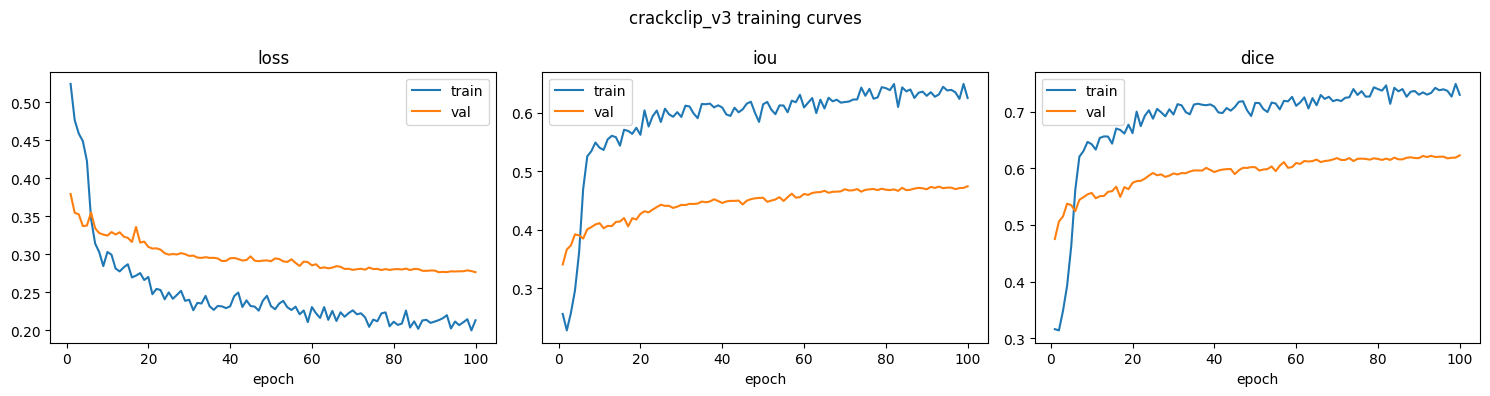

In [ ]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history["train"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["loss", "iou", "dice"]):
    ax.plot(epochs_ran, [m[metric] for m in history["train"]], label="train")
    ax.plot(epochs_ran, [m[metric] for m in history["val"]], label="val")
    ax.set_title(metric)
    ax.set_xlabel("epoch")
    ax.legend()

plt.suptitle(f"{RUN_NAME} training curves")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/training_curves.png", dpi=100)
plt.show()

## Evaluation of Model 

In [ ]:
ckpt = torch.load(f"{CKPT_DIR}/best.pth", map_location=device, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
best_val = ckpt.get("metrics", {})
epoch = ckpt.get("epoch", 0)
print(f"Best checkpoint  epoch={epoch}  val_iou={best_val['iou']:.4f}")

model.eval()
test_tracker = MetricTracker()

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing", ncols=80):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        masks = batch["mask"].to(device)
        out = model(pixel_values=pixel_values, input_ids=input_ids)
        logits = out.logits.unsqueeze(1)
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )
        test_tracker.update(logits, masks)

test_metrics = test_tracker.compute()
print(f"\nTest results — {RUN_NAME}")
for k, v in test_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

Best checkpoint  epoch=100  val_iou=0.4742


Testing: 100%|████████████████████████████████| 206/206 [00:11<00:00, 18.65it/s]


Test results — crackclip_v3
  iou         : 0.4715
  dice        : 0.6188
  precision   : 0.6616
  recall      : 0.7124


In [ ]:
model.eval()
per_class = defaultdict(lambda: {"iou": [], "dice": []})

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        masks = batch["mask"].to(device)
        prompts = batch["prompt"]

        out = model(pixel_values=pixel_values, input_ids=input_ids)
        logits = out.logits.unsqueeze(1)
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )

        pred = (torch.sigmoid(logits).squeeze(1) >= 0.5).float()

        for i, prompt in enumerate(prompts):
            p, gt = pred[i], masks[i].squeeze()
            inter = (p * gt).sum()
            iou = (inter / ((p + gt).clamp(0, 1).sum() + 1e-6)).item()
            dice = (2 * inter / (p.sum() + gt.sum() + 1e-6)).item()
            key = "crack" if "crack" in prompt.lower() else "drywall"
            per_class[key]["iou"].append(iou)
            per_class[key]["dice"].append(dice)

print("Per-class test results:")
for cls, vals in per_class.items():
    print(
        f"  {cls:10s}  IoU={np.mean(vals['iou']):.4f}  "
        f"Dice={np.mean(vals['dice']):.4f}  n={len(vals['iou'])}"
    )

Per-class test results:
  drywall     IoU=0.6008  Dice=0.7445  n=38
  crack       IoU=0.4430  Dice=0.5907  n=168


In [ ]:
model.eval()
viz_saved = False

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Saving preds", ncols=80):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        masks = batch["mask"].to(device)
        stems, prompts = batch["stem"], batch["prompt"]

        out = model(pixel_values=pixel_values, input_ids=input_ids)
        logits = out.logits.unsqueeze(1)
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )

        pred_bin = (torch.sigmoid(logits).squeeze(1) >= 0.5).cpu().numpy()

        for i, (stem, prompt) in enumerate(zip(stems, prompts)):
            dataset = "drywall" if stem.startswith("drywall") else "cracks"
            src_path = Path(PROCESSED_ROOT) / dataset / "images" / f"{stem}.jpg"
            src_img = cv2.imread(str(src_path))
            h, w = src_img.shape[:2]

            mask_out = cv2.resize(
                pred_bin[i].astype(np.uint8) * 255,
                (w, h),
                interpolation=cv2.INTER_NEAREST,
            )

            # morphological cleanup
            k = np.ones((5, 5), np.uint8)
            mask_out = cv2.morphologyEx(mask_out, cv2.MORPH_OPEN, k)
            mask_out = cv2.morphologyEx(mask_out, cv2.MORPH_CLOSE, k)

            slug = prompt.replace(" ", "_")
            cv2.imwrite(str(Path(PRED_DIR) / f"{stem}__{slug}.png"), mask_out)

        if not viz_saved:
            visualise_predictions(
                pixel_values,
                masks,
                logits,
                prompts,
                n=4,
                save_path=f"{VIZ_DIR}/sample_predictions.png",
            )
            viz_saved = True

print(f"Predictions → {PRED_DIR}")
print(f"Viz         → {VIZ_DIR}")

Saving preds: 100%|███████████████████████████| 206/206 [00:11<00:00, 17.25it/s]

Predictions → /kaggle/working/predictions/crackclip_v3
Viz         → /kaggle/working/visualisations/crackclip_v3


In [ ]:
import os

model.eval()
dummy_batch = next(iter(test_loader))
dummy_pixels = dummy_batch["pixel_values"][:1].to(device)
dummy_ids = dummy_batch["input_ids"][:1].to(device)

for _ in range(10):  # warmup
    with torch.no_grad():
        _ = model(pixel_values=dummy_pixels, input_ids=dummy_ids)

starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)
times = []

with torch.no_grad():
    for _ in range(50):
        starter.record()
        _ = model(pixel_values=dummy_pixels, input_ids=dummy_ids)
        ender.record()
        torch.cuda.synchronize()
        times.append(starter.elapsed_time(ender))

ckpt_mb = os.path.getsize(f"{CKPT_DIR}/best.pth") / 1024 / 1024
total_params = sum(p.numel() for p in model.parameters())
adapter_params = sum(p.numel() for a in model.adapters for p in a.parameters())

print(f"Inference  avg={np.mean(times):.1f}ms  std={np.std(times):.1f}ms")
print(
    f"Params     total={total_params / 1e6:.2f}M  adapters={adapter_params / 1e3:.1f}K"
)
print(f"Checkpoint {ckpt_mb:.1f} MB")

Inference  avg=47.8ms  std=0.8ms
Params     total=151.94M  adapters=1189.6K
Checkpoint 588.4 MB


In [ ]:
import shutil, json as _json

results = {
    RUN_NAME: {
        "val": best_val,
        "test": test_metrics,
        "per_class": {
            cls: {
                "iou": float(np.mean(vals["iou"])),
                "dice": float(np.mean(vals["dice"])),
                "n": len(vals["iou"]),
            }
            for cls, vals in per_class.items()
        },
        "inference_ms": float(np.mean(times)),
    }
}

with open(f"{METRICS_DIR}/results_{RUN_NAME}.json", "w") as f:
    _json.dump(results, f, indent=2)

print(_json.dumps(results, indent=2))

shutil.make_archive(f"/kaggle/working/{RUN_NAME}_results", "zip", "/kaggle/working")
print(f"\nDownload {RUN_NAME}_results.zip from the Output panel →")

{
  "crackclip_v3": {
    "val": {
      "iou": 0.4742,
      "dice": 0.6231,
      "precision": 0.6322,
      "recall": 0.7384,
      "loss": 0.2766
    },
    "test": {
      "iou": 0.4727,
      "dice": 0.6197,
      "precision": 0.6612,
      "recall": 0.7144
    },
    "per_class": {
      "drywall": {
        "iou": 0.6008472693593878,
        "dice": 0.744456581379238,
        "n": 38
      },
      "crack": {
        "iou": 0.44297507201277075,
        "dice": 0.590718698532631,
        "n": 168
      }
    },
    "inference_ms": 47.75710083007812
  }
}

Download crackclip_v3_results.zip from the Output panel →


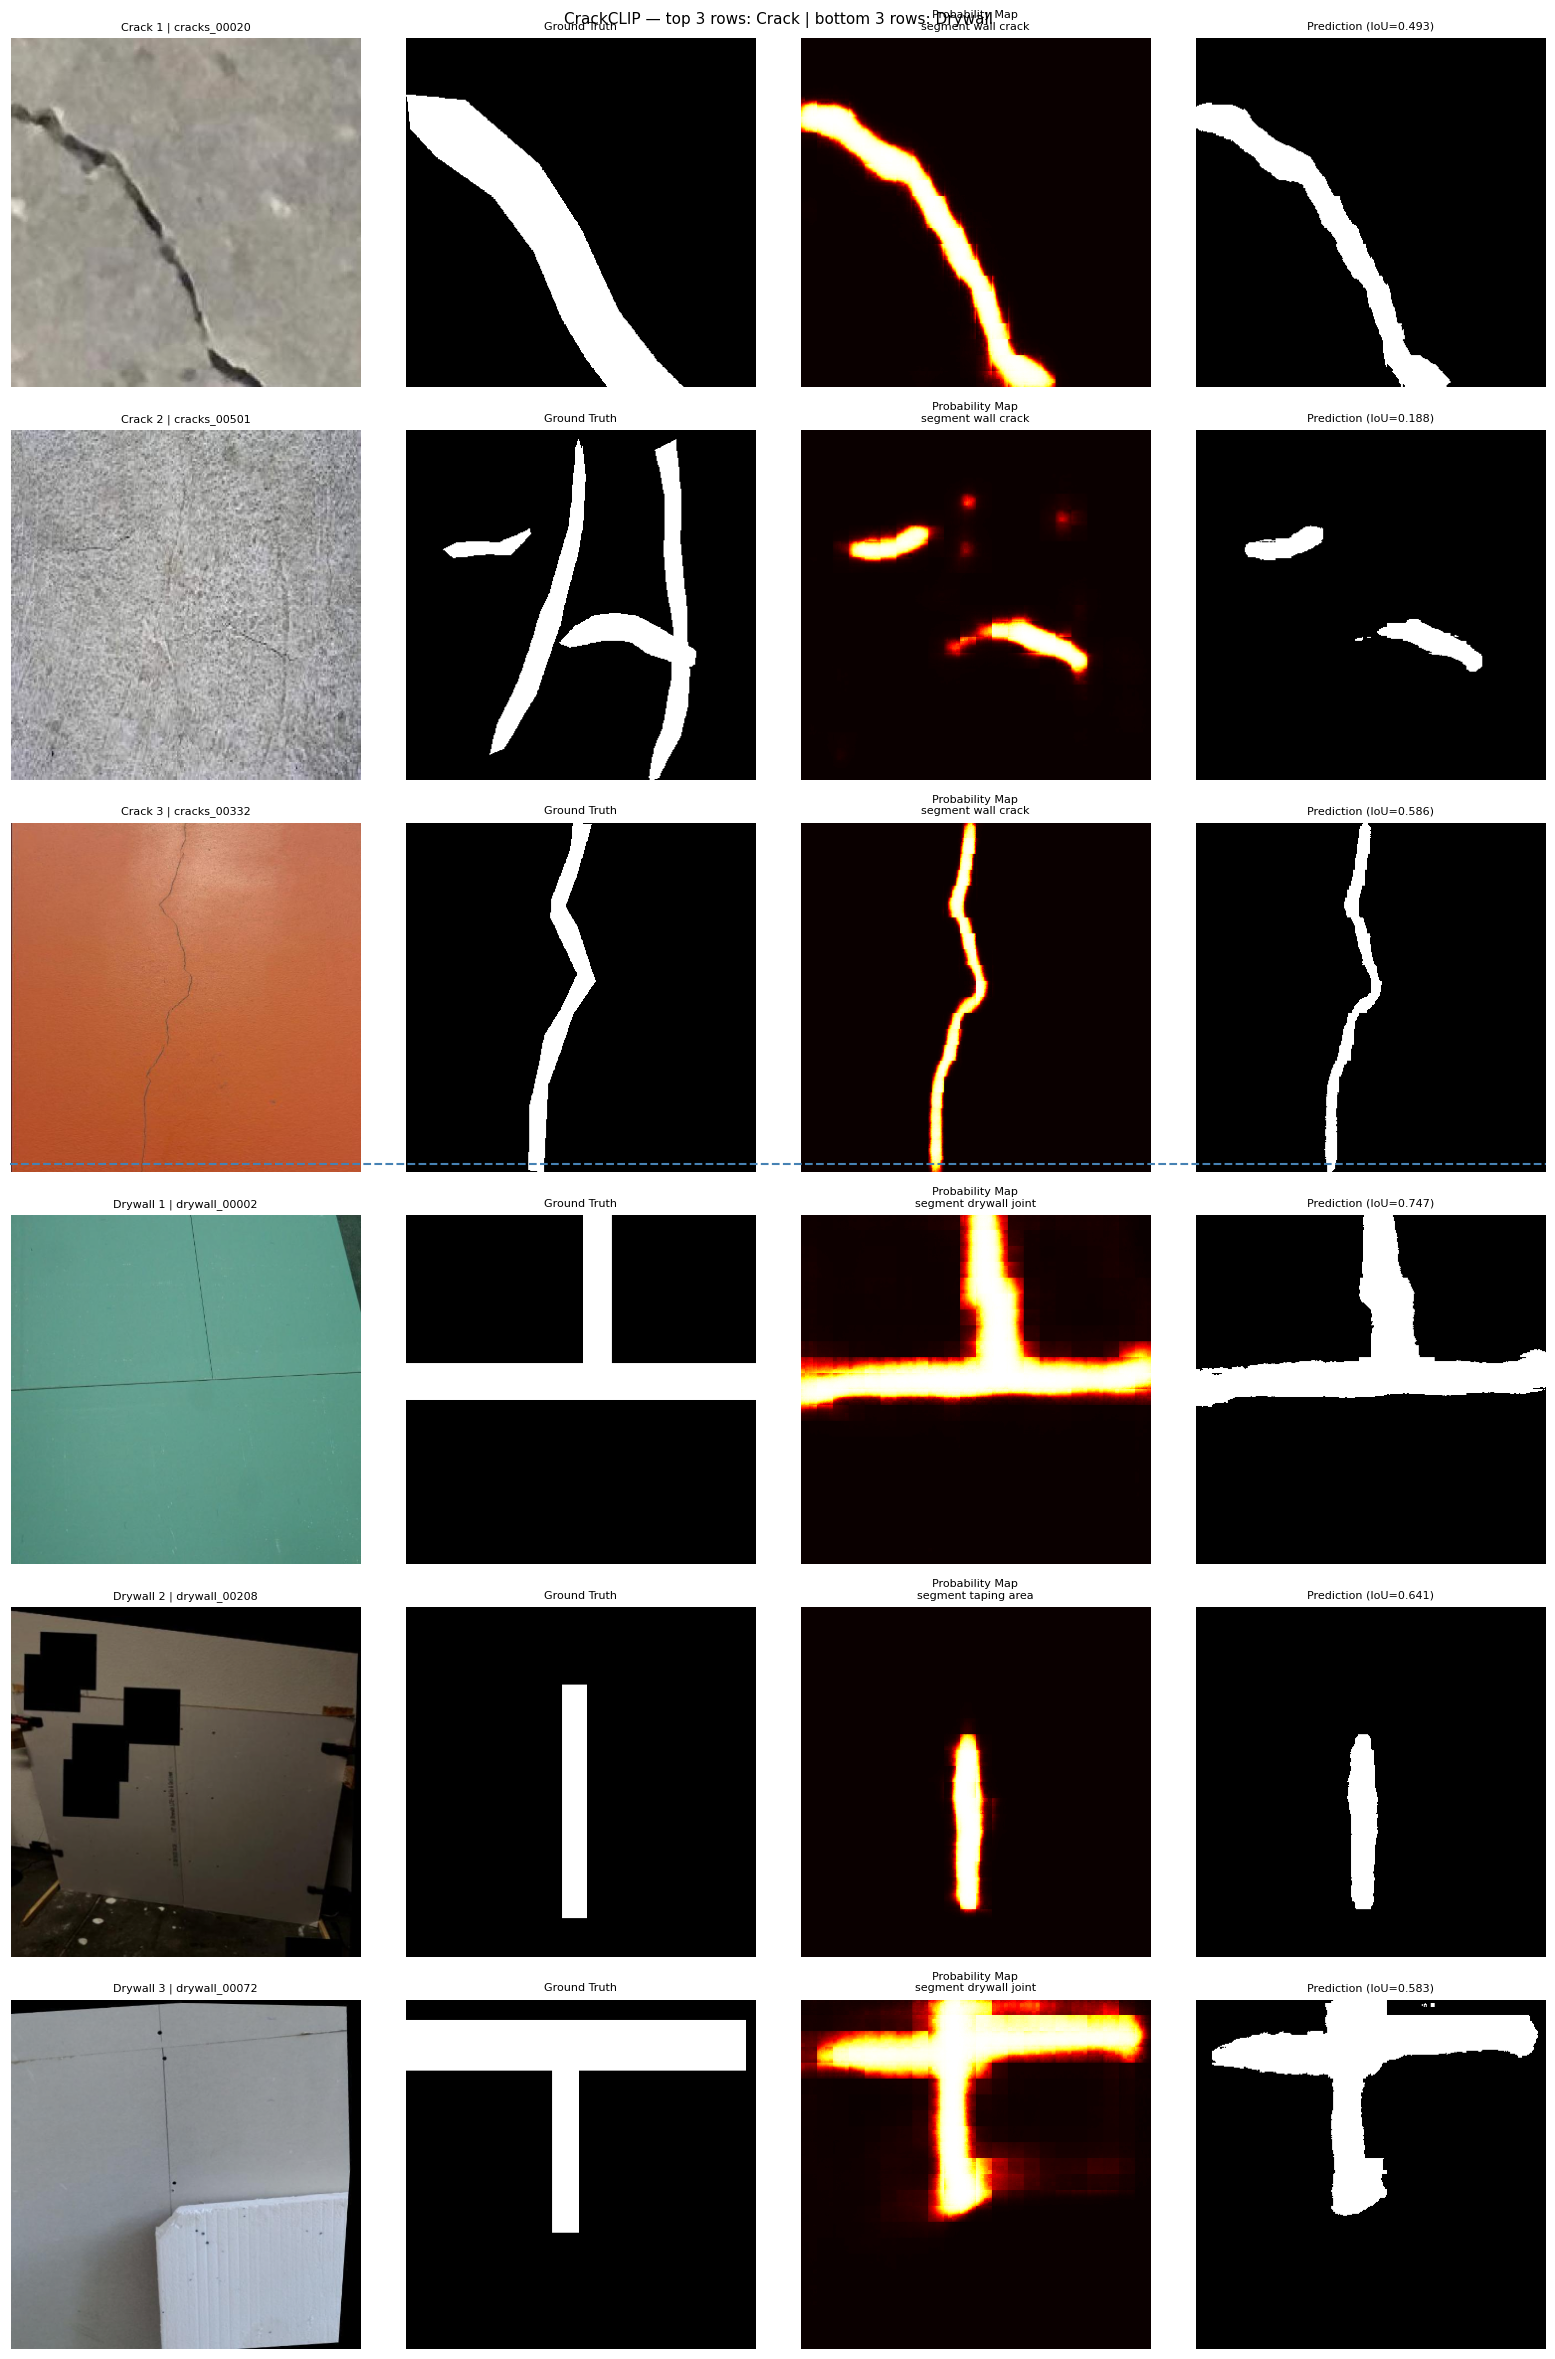

Saved → /kaggle/working/visualisations/crackclip_v3/sample_predictions.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def show_predictions_crackclip(model, loader, device, n_per_class=3, threshold=0.5):
    model.eval()

    crack_samples = []
    drywall_samples = []

    for batch in loader:
        for idx, prompt in enumerate(batch["prompt"]):
            cls = "crack" if "crack" in prompt.lower() else "drywall"

            sample = {
                "pixel_values": batch["pixel_values"][idx : idx + 1],
                "input_ids": batch["input_ids"][idx : idx + 1],
                "mask": batch["mask"][idx : idx + 1],
                "prompt": prompt,
                "stem": batch["stem"][idx],
            }

            if cls == "crack" and len(crack_samples) < n_per_class:
                crack_samples.append(sample)
            if cls == "drywall" and len(drywall_samples) < n_per_class:
                drywall_samples.append(sample)

        if len(crack_samples) == n_per_class and len(drywall_samples) == n_per_class:
            break

    all_samples = crack_samples + drywall_samples
    total = len(all_samples)

    all_probs = []
    all_preds = []

    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            for s in all_samples:
                pv = s["pixel_values"].to(device)
                ids = s["input_ids"].to(device)
                out = model(pixel_values=pv, input_ids=ids)
                logits = out.logits.unsqueeze(1).cpu()
                prob = torch.sigmoid(logits).squeeze(1)
                all_probs.append(prob)
                all_preds.append((prob >= threshold).float())

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    fig, axes = plt.subplots(total, 4, figsize=(16, 4 * total))
    if total == 1:
        axes = axes[np.newaxis, :]

    for i, s in enumerate(all_samples):
        img = s["pixel_values"][0].cpu()
        img = (img * std + mean).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        gt = s["mask"][0].numpy()
        prob_map = all_probs[i][0].numpy()
        pred = all_preds[i][0].numpy()

        inter = float((all_preds[i][0] * s["mask"][0]).sum())
        union = float(((all_preds[i][0] + s["mask"][0]).clamp(0, 1)).sum())
        iou = inter / (union + 1e-6)

        cls_label = "Crack" if i < n_per_class else "Drywall"
        row_num = (i % n_per_class) + 1

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{cls_label} {row_num} | {s['stem']}", fontsize=8)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray", vmin=0, vmax=1)
        axes[i, 1].set_title("Ground Truth", fontsize=8)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(prob_map, cmap="hot", vmin=0, vmax=1)
        axes[i, 2].set_title(f"Probability Map\n{s['prompt']}", fontsize=8)
        axes[i, 2].axis("off")

        axes[i, 3].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[i, 3].set_title(f"Prediction (IoU={iou:.3f})", fontsize=8)
        axes[i, 3].axis("off")

    divider_y = 1.0 - (n_per_class / total)
    fig.add_artist(
        plt.Line2D(
            [0.02, 0.98],
            [divider_y, divider_y],
            transform=fig.transFigure,
            color="steelblue",
            linewidth=1.5,
            linestyle="--",
        )
    )

    plt.suptitle(
        f"CrackCLIP — top {n_per_class} rows: Crack | bottom {n_per_class} rows: Drywall",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(f"{VIZ_DIR}/sample_predictions.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {VIZ_DIR}/sample_predictions.png")


show_predictions_crackclip(model, test_loader, device, n_per_class=3)

## Failure Cases 

In [ ]:
# per-image IoU on the full test set - CrackCLIP
model.eval()
per_image_results_cc = []

with torch.no_grad():
    for batch in test_loader:
        pv = batch["pixel_values"].to(device)
        ids = batch["input_ids"].to(device)
        masks = batch["mask"]
        prompts = batch["prompt"]
        stems = batch["stem"]

        out = model(pixel_values=pv, input_ids=ids)
        logits = out.logits.unsqueeze(1).cpu()
        preds = (torch.sigmoid(logits).squeeze(1) >= 0.5).float()

        for i in range(len(stems)):
            pred = preds[i]
            gt = masks[i]

            inter = float((pred * gt).sum())
            union = float(((pred + gt).clamp(0, 1)).sum())
            iou = inter / (union + 1e-6)
            fp_ratio = float(pred.sum()) / (float(gt.sum()) + 1e-6)

            per_image_results_cc.append(
                {
                    "stem": stems[i],
                    "prompt": prompts[i],
                    "iou": round(iou, 4),
                    "pred_px": int(pred.sum()),
                    "gt_px": int(gt.sum()),
                    "fp_ratio": round(fp_ratio, 2),
                }
            )

per_image_results_cc.sort(key=lambda x: x["iou"])

print("── 10 worst predictions ─────────────────────────────")
for r in per_image_results_cc[:10]:
    print(
        f"  IoU={r['iou']:.3f}  pred_px={r['pred_px']:5d}  "
        f"gt_px={r['gt_px']:5d}  fp_ratio={r['fp_ratio']:.1f}  "
        f"{r['prompt']:<25}  {r['stem']}"
    )

print("\n── 5 best predictions ───────────────────────────────")
for r in per_image_results_cc[-5:]:
    print(f"  IoU={r['iou']:.3f}  {r['prompt']:<25}  {r['stem']}")

── 10 worst predictions ─────────────────────────────
  IoU=0.015  pred_px= 3447  gt_px=   51  fp_ratio=67.6  segment surface crack      cracks_00547
  IoU=0.065  pred_px= 3788  gt_px=  588  fp_ratio=6.4  segment surface crack      cracks_00739
  IoU=0.072  pred_px= 2202  gt_px=  306  fp_ratio=7.2  segment surface crack      cracks_00741
  IoU=0.088  pred_px= 4065  gt_px=  387  fp_ratio=10.5  segment wall crack         cracks_00645
  IoU=0.131  pred_px=  528  gt_px= 2221  fp_ratio=0.2  segment crack              cracks_00740
  IoU=0.153  pred_px= 2339  gt_px=  749  fp_ratio=3.1  segment crack              cracks_00115
  IoU=0.153  pred_px= 4146  gt_px=  656  fp_ratio=6.3  segment wall crack         cracks_00614
  IoU=0.153  pred_px= 4215  gt_px=  819  fp_ratio=5.2  segment crack              cracks_00199
  IoU=0.162  pred_px= 3421  gt_px=  632  fp_ratio=5.4  segment crack              cracks_00210
  IoU=0.165  pred_px= 3786  gt_px= 1006  fp_ratio=3.8  segment crack              cracks_

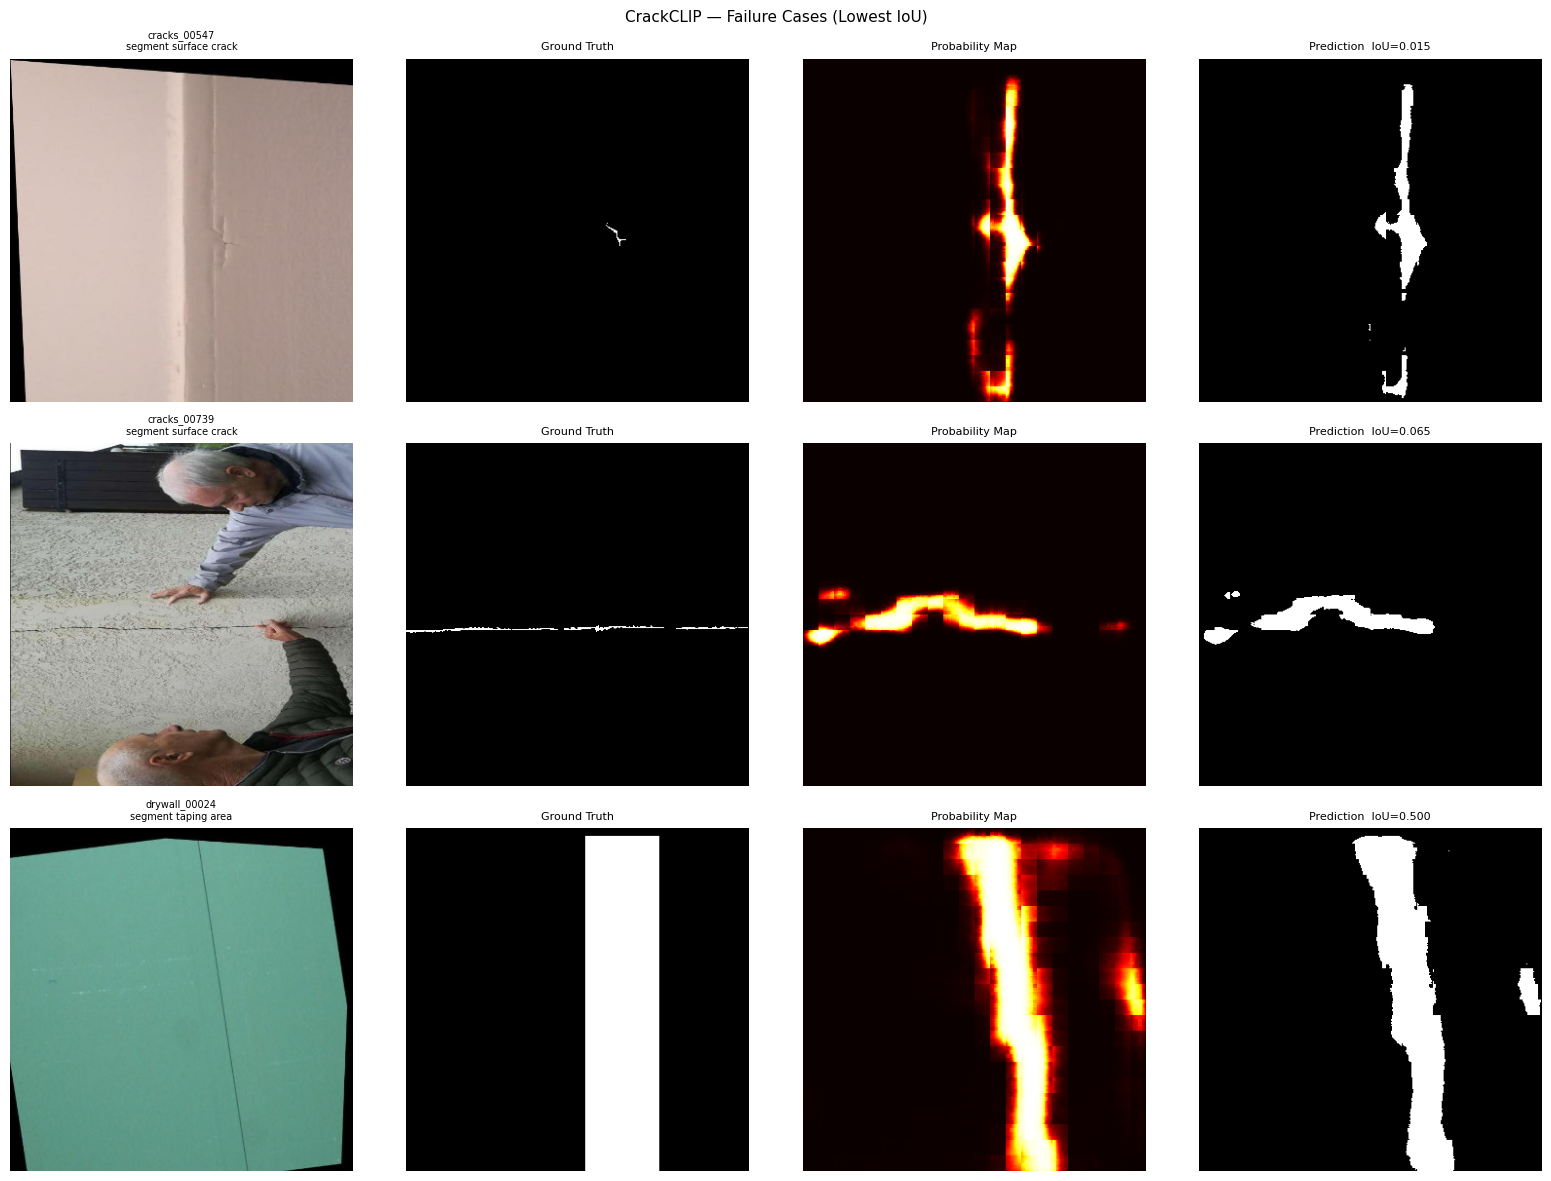

Saved → /kaggle/working/visualisations/crackclip_v3/failure_cases.png


In [ ]:
def show_failures_crackclip(worst_results, processed_root, device, n=3, threshold=0.5):
    model.eval()

    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for i, r in enumerate(worst_results[:n]):
        stem = r["stem"]
        prompt = r["prompt"]
        ds = "drywall" if stem.startswith("drywall") else "cracks"

        img_path = Path(processed_root) / ds / "images" / f"{stem}.jpg"
        mask_path = Path(processed_root) / ds / "masks" / f"{stem}.png"

        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        img_resized = cv2.resize(img, (352, 352))
        mask_resized = cv2.resize(mask, (352, 352), interpolation=cv2.INTER_NEAREST)

        inputs = processor(
            images=img_resized, text=prompt, return_tensors="pt", padding=True
        )
        pv = inputs["pixel_values"].to(device)
        ids = inputs["input_ids"].to(device)

        with torch.no_grad():
            out = model(pixel_values=pv, input_ids=ids)
            logits = out.logits.unsqueeze(1).cpu()
            prob = torch.sigmoid(logits).squeeze().numpy()
            pred = (prob >= threshold).astype(float)

        gt = mask_resized / 255.0

        axes[i, 0].imshow(img_resized)
        axes[i, 0].set_title(f"{stem}\n{prompt}", fontsize=7)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth", fontsize=8)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(prob, cmap="hot", vmin=0, vmax=1)
        axes[i, 2].set_title("Probability Map", fontsize=8)
        axes[i, 2].axis("off")

        axes[i, 3].imshow(pred, cmap="gray")
        axes[i, 3].set_title(f"Prediction  IoU={r['iou']:.3f}", fontsize=8)
        axes[i, 3].axis("off")

    plt.suptitle("CrackCLIP — Failure Cases (Lowest IoU)", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{VIZ_DIR}/failure_cases.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {VIZ_DIR}/failure_cases.png")


# worst 2 cracks + worst 1 drywall
worst_cracks = [r for r in per_image_results_cc if "crack" in r["prompt"]][:2]
worst_drywall = [r for r in per_image_results_cc if "taping" in r["prompt"]][:1]

show_failures_crackclip(worst_cracks + worst_drywall, PROCESSED_ROOT, device, n=3)